# **Histogram**


## Objectives


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Working with database


#### Download the database file.


#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 174.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 191.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 173.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 150.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [15]:
conn = sqlite3.connect('survey-data.sqlite')

## Basic SQL queries

**Count the number of rows in the table**


In [16]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

List all tables**


In [17]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Group data by age**


In [18]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data with Histograms and Bar charts


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


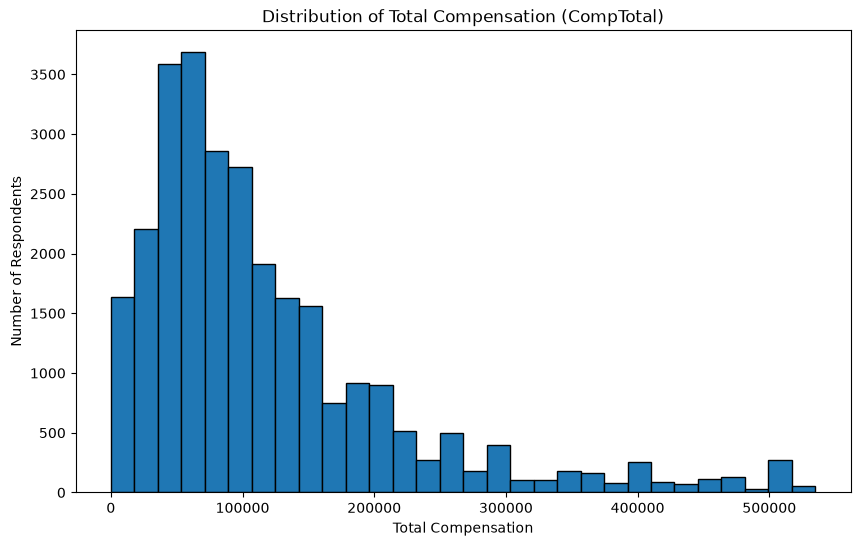

In [19]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df_comp = pd.read_sql_query(QUERY, conn)
df_comp['CompTotal'] = pd.to_numeric(df_comp['CompTotal'], errors='coerce')

# Remove extreme outliers using IQR
Q1 = df_comp['CompTotal'].quantile(0.25)
Q3 = df_comp['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_comp_clean = df_comp[
    df_comp['CompTotal'].between(lower, upper)
]

plt.figure(figsize=(10, 6))
plt.hist(df_comp_clean['CompTotal'], bins=30, edgecolor='black')

plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Total Compensation (CompTotal)')
plt.show()


**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


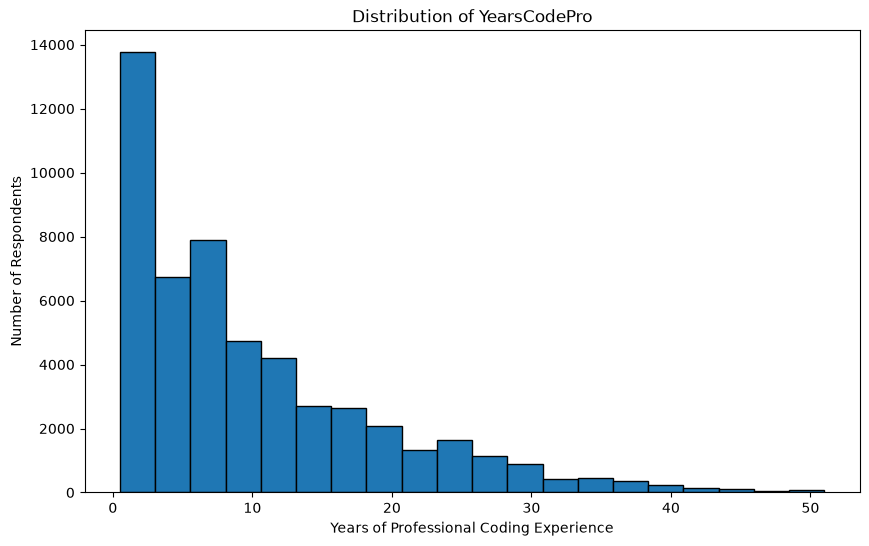

In [21]:
# 1.2 Histogram of YearsCodePro
QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
"""
df_years = pd.read_sql_query(QUERY, conn)

# Convert the special text values to numeric values
df_years["YearsCodePro_num"] = (
    df_years["YearsCodePro"]
    .replace({"Less than 1 year": 0.5, "More than 50 years": 51})
    .pipe(pd.to_numeric, errors="coerce")
)
df_years = df_years.dropna(subset=["YearsCodePro_num"])

plt.figure(figsize=(10, 6))
plt.hist(df_years["YearsCodePro_num"], bins=20, edgecolor="black")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")
plt.title("Distribution of YearsCodePro")
plt.show()


### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


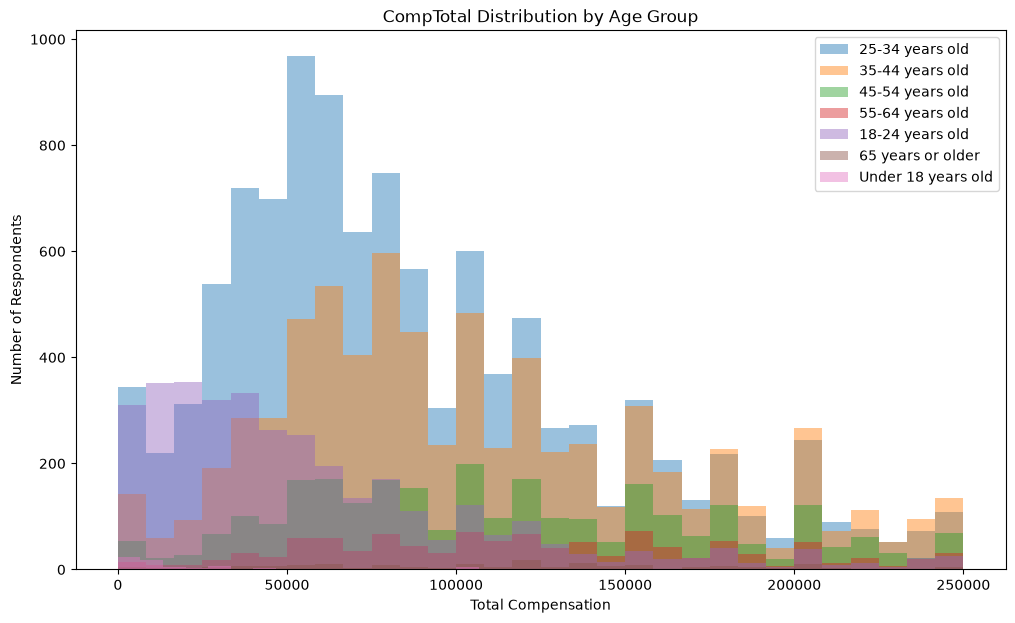

In [23]:
# Remove extreme CompTotal outliers
Q1 = df_age_comp['CompTotal'].quantile(0.25)
Q3 = df_age_comp['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

df_age_comp = df_age_comp[
    df_age_comp['CompTotal'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
]

plt.figure(figsize=(12, 7))
age_groups = [age for age in df_age_comp['Age'].dropna().unique()
              if age != 'Prefer not to say']
for age in age_groups:
    values = df_age_comp.loc[df_age_comp['Age'] == age, 'CompTotal'].dropna()
    plt.hist(values, bins=30, alpha=0.45, label=age)

plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.title('CompTotal Distribution by Age Group')
plt.legend()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [30]:
print(df_search['TimeSearching'].unique())

<ArrowStringArray>
[       '30-60 minutes a day',       '60-120 minutes a day',
        '15-30 minutes a day', 'Less than 15 minutes a day',
     'Over 120 minutes a day']
Length: 5, dtype: str

In [31]:
time_midpoints = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

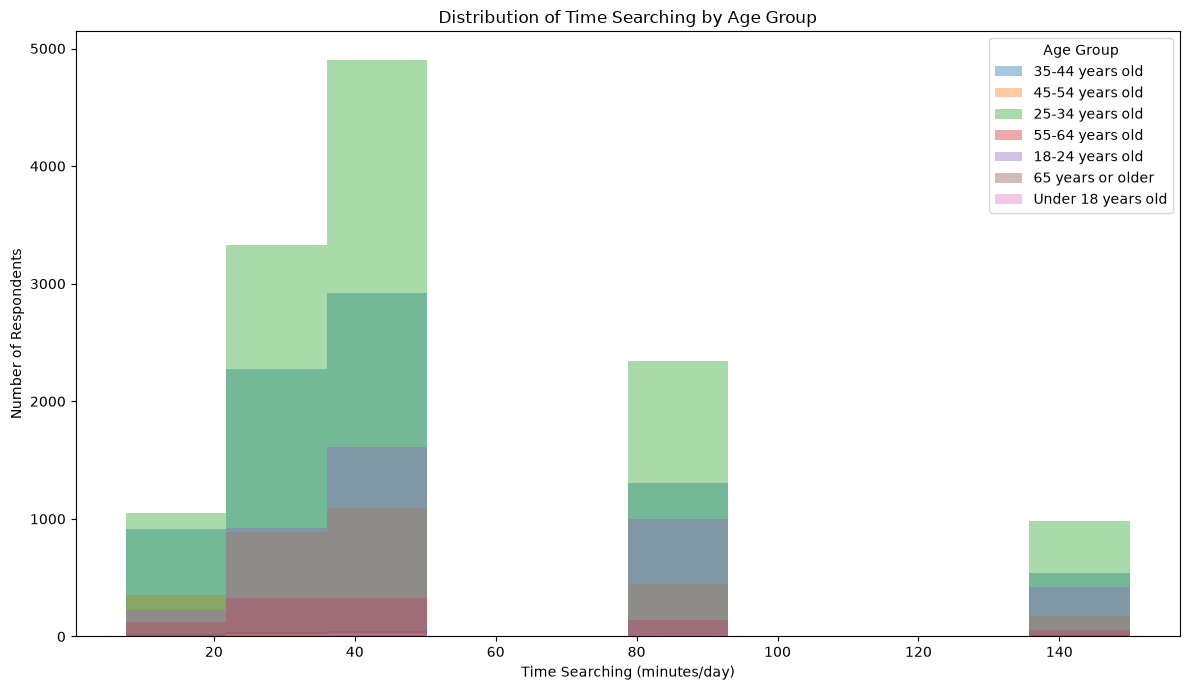

In [32]:
QUERY = """
SELECT Age, TimeSearching
FROM main
WHERE Age IS NOT NULL AND TimeSearching IS NOT NULL
"""

df_search = pd.read_sql_query(QUERY, conn)

df_search['TimeSearchingMinutes'] = df_search['TimeSearching'].map(time_midpoints)

age_groups = [
    age for age in df_search['Age'].dropna().unique()
    if age != 'Prefer not to say'
]

plt.figure(figsize=(12,7))

for age in age_groups:
    values = df_search.loc[
        df_search['Age'] == age, 'TimeSearchingMinutes'
    ].dropna()

    plt.hist(values, bins=10, alpha=0.4, label=age)

plt.xlabel('Time Searching (minutes/day)')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Time Searching by Age Group')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Bar chart of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Bar Chart of Top 5 Most Desired Databases.


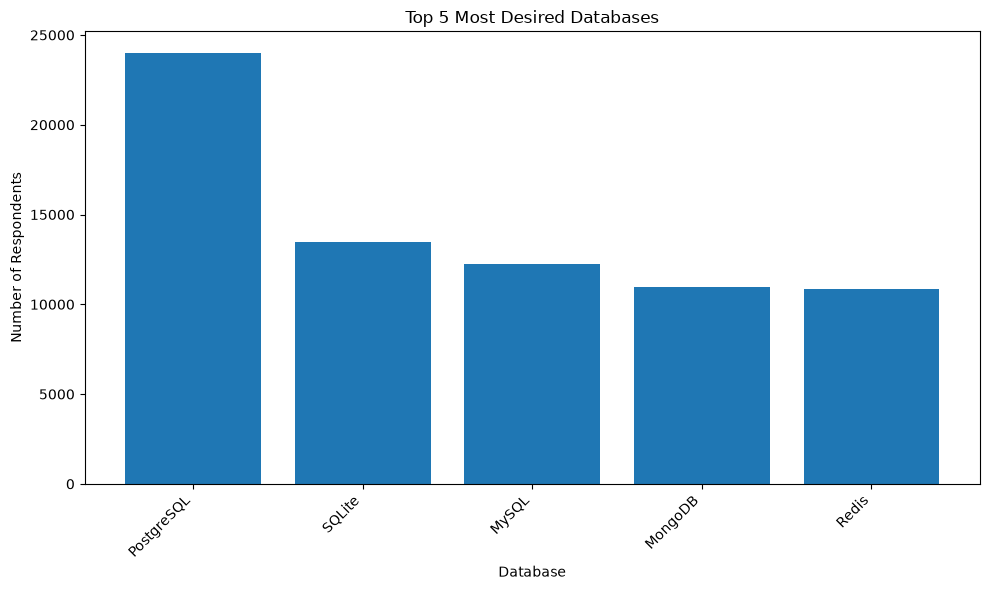

In [38]:
# 3.1 Histogram of Most Desired Databases (top 5)
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
df_db = pd.read_sql_query(QUERY, conn)

# The column can contain multiple databases separated by semicolons.
db_counts = (
    df_db["DatabaseWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(5)
)

plt.figure(figsize=(10, 6))
plt.bar(db_counts.index, db_counts.values)
plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.title("Top 5 Most Desired Databases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**3.2 Bar chart of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


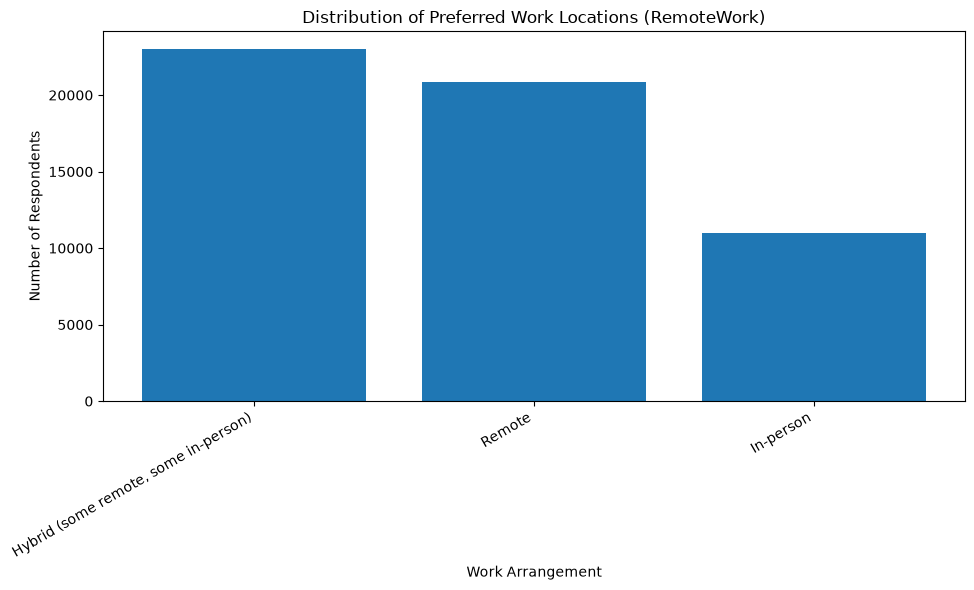

In [15]:
# 3.2 Histogram of Preferred Work Locations (RemoteWork)
QUERY = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
"""
df_remote = pd.read_sql_query(QUERY, conn)

remote_counts = df_remote["RemoteWork"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(remote_counts.index, remote_counts.values)
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Preferred Work Locations (RemoteWork)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 4. Visualizing Comparison of Data


**4.1 Bar Chart of Median CompTotal for Ages 45 to 60

Objective: Plot the Bar for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


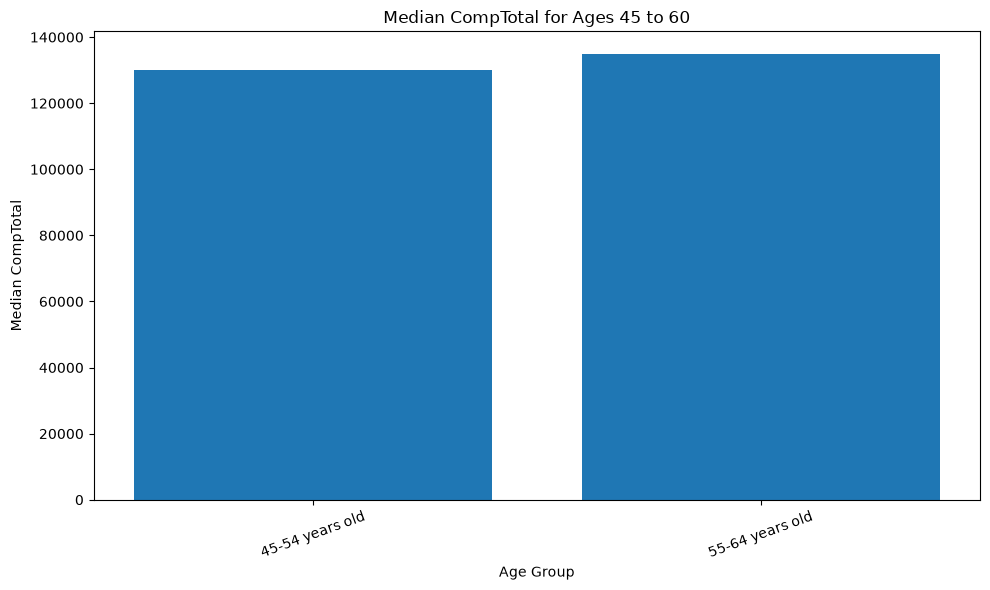

In [16]:
# 4.1 Histogram of Median CompTotal for Ages 45 to 60
# The survey stores Age as groups, so use the groups covering ages 45-60:
# 45-54 years old and 55-64 years old.
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL
"""
df_midcareer = pd.read_sql_query(QUERY, conn)
df_midcareer["CompTotal"] = pd.to_numeric(df_midcareer["CompTotal"], errors="coerce")
df_midcareer = df_midcareer.dropna(subset=["CompTotal"])

median_comp = df_midcareer.groupby("Age")["CompTotal"].median()

plt.figure(figsize=(10, 6))
plt.bar(median_comp.index, median_comp.values)
plt.xlabel("Age Group")
plt.ylabel("Median CompTotal")
plt.title("Median CompTotal for Ages 45 to 60")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the Bar for `JobSat` scores based on respondents' years of professional coding experience.


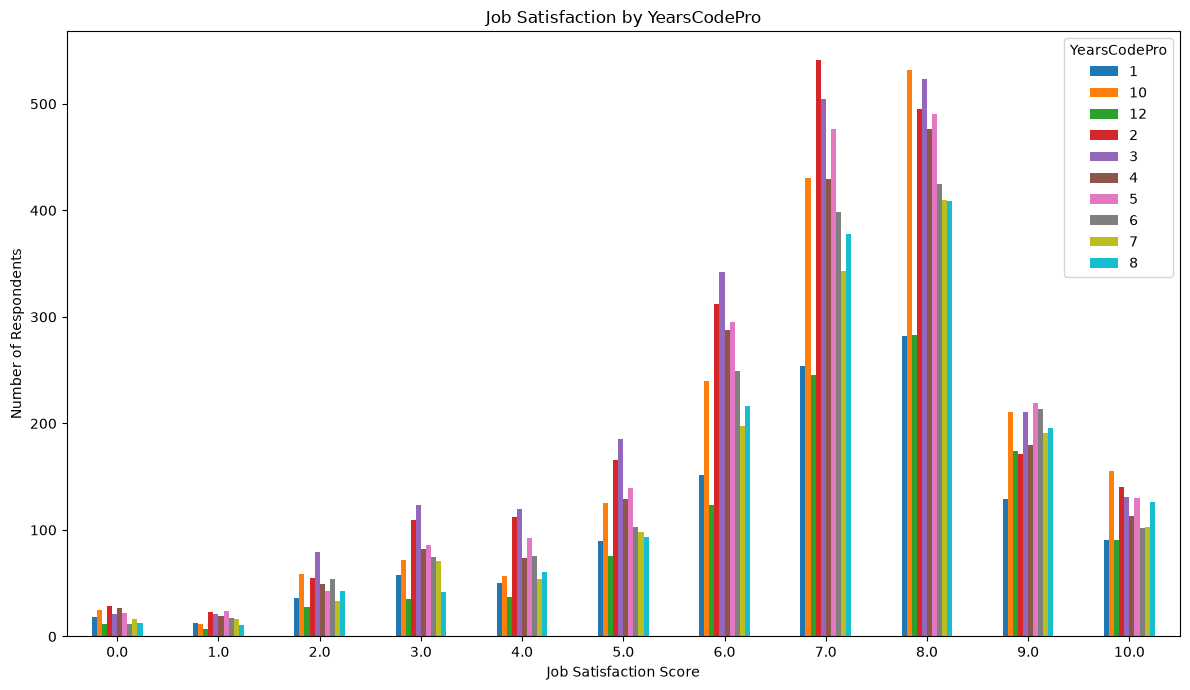

In [17]:
# 4.2 Histogram of Job Satisfaction (JobSat) by YearsCodePro
QUERY = """
SELECT YearsCodePro, JobSat
FROM main
WHERE YearsCodePro IS NOT NULL AND JobSat IS NOT NULL
"""
df_jobsat = pd.read_sql_query(QUERY, conn)
df_jobsat["JobSat"] = pd.to_numeric(df_jobsat["JobSat"], errors="coerce")
df_jobsat = df_jobsat.dropna(subset=["JobSat"])

# Keep the most common experience groups for a readable comparison.
common_years = df_jobsat["YearsCodePro"].value_counts().head(10).index
df_jobsat = df_jobsat[df_jobsat["YearsCodePro"].isin(common_years)]

jobsat_table = pd.crosstab(df_jobsat["JobSat"], df_jobsat["YearsCodePro"])

jobsat_table.plot(kind="bar", figsize=(12, 7))
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")
plt.title("Job Satisfaction by YearsCodePro")
plt.xticks(rotation=0)
plt.legend(title="YearsCodePro")
plt.tight_layout()
plt.show()


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [18]:
# Close the database connection
conn.close()

### Summary


- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.
